In [17]:
import os
import matplotlib.pyplot as plt
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
import pandas as pd

# from cosmographi.source.base import TransientSource




from tinygp import GaussianProcess, kernels


import jaxopt



The first step is going to be to try to build the kernel. 

In [18]:
# the first step is going to be to try to build the kernel
sigma = Param("sigma", shape=(), description="sigma parameter")
scale = Param("scale", shape=(), description="scale parameter")
kernel = kernels.quasisep.Exp(scale=scale, sigma=sigma)

#TODO: REMEMBER THIS PROCESS GIVES YOU THE FLUX DON'T FORGET TO CONVERT

It would now be nice to have some data to condition or gp likelihood on. I am especialy interested in sepparating different objects vs different time stamps of the same object (#TODO read up on time series analysis). 
To get around this and figure out how to use tinygo before tsa, I will try to infer the hyperparameters of the kernel for each object 
sepparatly. Then, I will look at the distirbution of the hyperparameters, and to generate new lightcurves I will sample from said
distribution of hyperparameters and plug in into a gp to generate the luminosity at different time stamps.
To save time on the data acquisition, I will follow the extremly scientific method of eyeballing datapoints from the lightcurves published in this paper: https://arxiv.org/pdf/1803.06436. (#TODO get better data). Note that there is also bias in terms of what points I included in my data. 


In [19]:
# Our next step is to prep our extremly scientific and accurate  and not sketchy at all data 

df = pd.read_csv("bad_agn_data.csv")
source_1 = jnp.asarray(df[df['source'] == 1].to_numpy())
source_2 = jnp.asarray(df[df['source'] == 2].to_numpy())
source_3 = jnp.asarray(df[df['source'] == 3].to_numpy())
source_4 = jnp.asarray(df[df['source'] == 4].to_numpy())
source_5 = jnp.asarray(df[df['source'] == 5].to_numpy())

print(source_1)

print(source_1[:, 1])
print(source_1[:, 2])

[[    1     0 14475]
 [    1    50 14500]
 [    1   100 14450]
 [    1   200 14460]
 [    1   300 14465]
 [    1   400 14473]
 [    1   500 14532]
 [    1   600 14510]
 [    1   700 14450]
 [    1   800 14525]
 [    1   900 14525]]
[  0  50 100 200 300 400 500 600 700 800 900]
[14475 14500 14450 14460 14465 14473 14532 14510 14450 14525 14525]


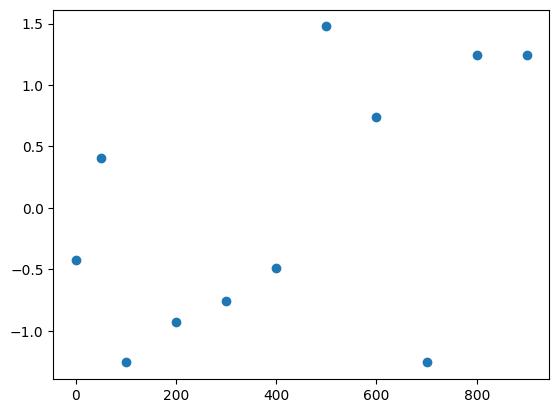

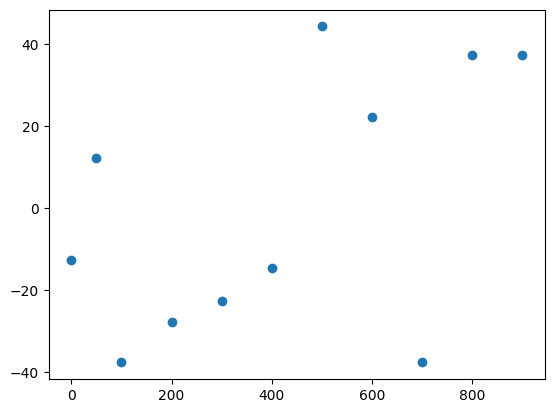

In [20]:
y_mean = jnp.mean(source_1[:, 2])
y_sd = jnp.std(source_1[:, 2])
y_standarized = (source_1[:, 2] - y_mean) / y_sd

plt.scatter(source_1[:, 1], y_standarized)
plt.show()

plt.scatter(source_1[:, 1], source_1[:, 2] - y_mean)
plt.show()

In [21]:
def build_gp(theta: tuple[Param], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale, log_noise) parameters.
    """
    log_sigma, log_scale, log_noise = theta
    kernel = kernels.quasisep.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=jnp.exp(log_noise)**2)

(Array(-1.4895169, dtype=float32), Array(4.583329, dtype=float32), Array(-0.02608429, dtype=float32))


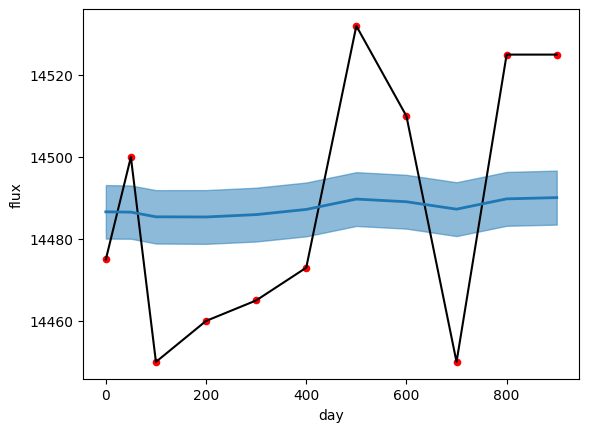

In [22]:
# Before circling over all samples, I want to test if it works for just one. 
# I will pick some bad values to initialize the gaussian process #TODO: FIgrue out how to pick good ones
scale = Param("scale", value=200.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=35.0, shape=(), description="sigma parameter")
noise = Param("noise", value=10.0, shape=(), description="noise parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)), jnp.log(float(noise.value)))


def neg_log_likelihood(theta, X, y):
    gp = build_gp(theta, X)
    return -gp.log_probability(y)

solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood)
soln = solver.run(theta, X=source_1[:, 1], y=y_standarized)

gp = build_gp(soln.params, source_1[:, 1])

print(soln.params)

cond_gp = gp.condition(y_standarized).gp


mu, var = cond_gp.loc, cond_gp.variance



plt.plot(source_1[:, 1], source_1[:, 2], color = "k")
plt.scatter(source_1[:, 1], source_1[:, 2], color="red", s=20)
plt.fill_between(source_1[:, 1], y_mean + y_sd * (mu + np.sqrt(var)), y_mean + y_sd * (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(source_1[:, 1], y_mean + y_sd * mu, color="C0", lw=2)
# plt.xlim(source_1[:, 1].min(), 1000)
plt.xlabel("day")
_ = plt.ylabel("flux")

The reuslt is very obviously very bad. I am, however, usure if this is a gp process. As we can see from the scatterplots above, the information content was probably pretty low, it does just look like random noise. In retrospect, I should have simulated the data the same way I did for the dummy AGN models in agn_simplified.ipynb. 

That is what we are going to try next. After this, I will try using some real (or ar least more accirately simulated) data. 

0.012147059


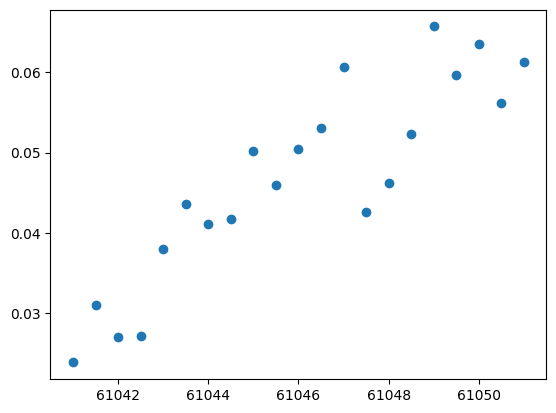

In [23]:
from astropy.time import Time

t_i = Time("2026-01-01T00:00:00").mjd
sample_times = jnp.array([t_i + 0.0, t_i + 0.5, t_i + 1.0, t_i + 1.5, t_i + 2.0, t_i + 2.5, t_i + 3.0, t_i + 3.5, t_i + 4.0, t_i + 4.5, 
                         t_i + 5.0, t_i + 5.5, t_i + 6.0, t_i + 6.5, t_i + 7.0, t_i + 7.5, t_i + 8.0, t_i + 8.5, t_i + 9.0, t_i + 9.5, t_i + 10.0])
a = 0.02
d = 0.04
true_b_value = 0.25
true_c_value = t_i - 0.6
non_lin_samples = []
for time in sample_times:
    non_lin_samples.append(np.random.normal(loc=a*np.sin(true_b_value * time - true_c_value) + d, scale = 0.005))
samples_jnp_non_lin = jnp.array(non_lin_samples)

plt.scatter(sample_times, samples_jnp_non_lin)

print(jnp.std(samples_jnp_non_lin))

(Array(-3.0673354, dtype=float32), Array(4.518125, dtype=float32), Array(-5.536781, dtype=float32))
[0.025746   0.02878859 0.02842253 0.03021919 0.03669067 0.04112476
 0.04176565 0.04335964 0.04752    0.04761716 0.05028385 0.0527355
 0.05474897 0.04782189 0.04878822 0.05371463 0.06080584 0.06042135
 0.06125972 0.05871325 0.06012264]


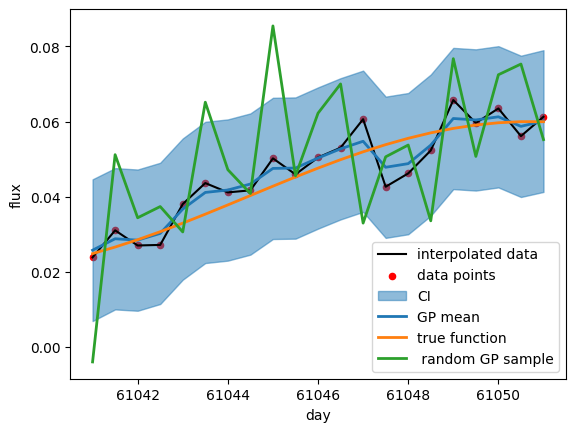

In [24]:
scale = Param("scale", value=2.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=0.012, shape=(), description="sigma parameter")
noise = Param("noise", value=0.005, shape=(), description="noise parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)), jnp.log(float(noise.value)))

soln = solver.run(theta, X=sample_times, y=samples_jnp_non_lin)

gp = build_gp(soln.params, sample_times)

print(soln.params)

cond_gp = gp.condition(samples_jnp_non_lin).gp


mu, var = cond_gp.loc, cond_gp.variance

print(mu)



plt.plot(sample_times, samples_jnp_non_lin, color = "k")
plt.scatter(sample_times, samples_jnp_non_lin, color="red", s=20)
plt.fill_between(sample_times, (mu + np.sqrt(var)), (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(sample_times, mu, color="C0", lw=2)
plt.plot(sample_times, a*np.sin(true_b_value * sample_times - true_c_value) + d, color="C1", lw=2)
plt.plot(sample_times, cond_gp.sample(jax.random.PRNGKey(42)), color="C2", lw=2)
plt.legend(["interpolated data", "data points", "CI", "GP mean", "true function", " random GP sample"])
plt.xlabel("day")
_ = plt.ylabel("flux")

Success!! Now we'll try using some simulated data. I will use lightcrvelynx, but ion the future I wshoudl train on raw data to avoid carrying over any biases lighcurvelynx may have. 
I will use all of the settings from the lightcurvelynx demo: https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/agn.html#AGN-Damped-Random-Walk-Example
(note that it uses DRW). However, I will use fixed values for redshift, blackhole mass, etc. since I only want to model 1 AGN for now (this will change in the future to get the distribution of the gp hyperparameters)

In [25]:
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.plotting import plot_lightcurves

passband_group = PassbandGroup.from_preset(
    preset="LSST",
)
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",
)

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
import numpy as np
from lightcurvelynx.survey_info import SurveyInfo

redshift = 0.5
bh_mass = 10**0.8
edd_ratio = 0.01

radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=redshift,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=redshift,
    blackhole_mass=bh_mass,
    ra=radec.ra,
    dec=radec.dec,
    edd_ratio=edd_ratio,
)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

rng = np.random.default_rng(42)

df = simulate_lightcurves(
    model=model,
    num_samples=10,
    survey_info=survey_info,
    rng=rng,
)
# params is too large to show =)
df.drop(columns=["params"])

Simulating: 100%|██████████| 10/10 [00:02<00:00,  3.67obj/s]


id          ra        dec  nobs            t0    z  \
0   0   39.471474 -68.315194   764  60980.001582  0.5   
1   1  330.597361  -2.175984   837  60980.001582  0.5   
2   2  123.395749  -3.154268   819  60980.001582  0.5   
3   3  295.309389 -51.002215   861  60980.001582  0.5   
4   4  189.970131  -2.213922   822  60980.001582  0.5   
5   5  175.368555 -16.462005   814  60980.001582  0.5   
6   6   62.643036   3.570605   294  60980.001582  0.5   
7   7   39.043406   6.363403   183  60980.001582  0.5   
8   8  338.926246 -27.375931   817  60980.001582  0.5   
9   9   58.615816  -5.691423   815  60980.001582  0.5   

                                          lightcurve  
0  [{mjd: 60980.043175, filter: 'r', flux: 185.55...  
1  [{mjd: 61181.433816, filter: 'z', flux: 662.30...  
2  [{mjd: 61000.332013, filter: 'i', flux: 104.72...  
3  [{mjd: 61160.317544, filter: 'z', flux: -708.8...  
4  [{mjd: 61098.214129, filter: 'y', flux: -326.8...  
5  [{mjd: 61072.338941, filter: 'z', flux: -160.3...  
6  [{mjd: 61004.058721, filter: 'g', flux: -369.5...  
7  [{mjd: 61000.140202, filter: 'g', flux: 111.96...  
8  [{mjd: 60981.139072, filter: 'r', flux: -239.2...  
9  [{mjd: 61000.19978, filter: 'u', flux: 129.716...

(764, 2)
0.9999999


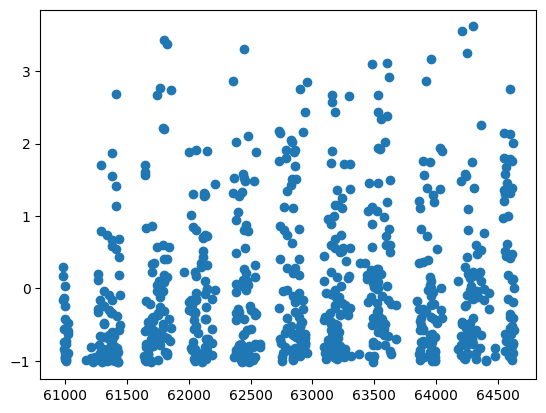

In [32]:
# print(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])


data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]].to_numpy())

print(jnp.shape(data))

x = data[:, 0]
y = data[:, 1]
y_mean = jnp.mean(y)
y_sd = jnp.std(y)
y_standarized = (y - y_mean) / y_sd


plt.scatter(data[:, 0], y_standarized)

print(jnp.std(y_standarized))


That scatterplot is really discouraging. The information content doe snot seem great...

(Array(-10.414592, dtype=float32), Array(-2.8507872, dtype=float32), Array(0.00025719, dtype=float32))
[ 1.4901161e-08  0.0000000e+00  0.0000000e+00  0.0000000e+00
  5.9604645e-08  0.0000000e+00  0.0000000e+00  5.9604645e-08
  5.9604645e-08  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  2.9802322e-08  5.9604645e-08  5.9604645e-08
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  2.9802322e-08  0.0000000e+00  0.0000000e+00
  5.9604645e-08  5.9604645e-08  5.9604645e-08  5.9604645e-08
  0.0000000e+00  1.1920929e-07  5.9604645e-08  2.9802322e-08
  0.0000000e+00 -7.4505806e-09  0.0000000e+00  0.0000000e+00
  5.9604645e-08  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  5.9604645e-08 -1.1920929e-07  0.0000000e+00
  5.9604645e-08  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  2.9802322e-08  0.0000000e+00  0.0000000e+00 -5.9604645e-08
  0.0000000e+00  5.9604645e-08  0.0000000e+

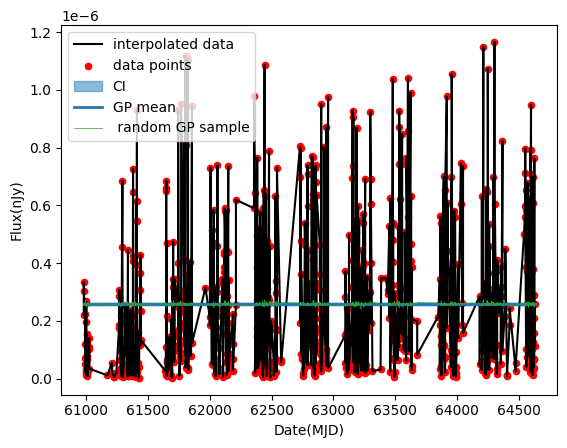

In [40]:
scale = Param("scale", value=100.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=1, shape=(), description="sigma parameter")
noise = Param("noise", value=0.01, shape=(), description="noise parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)), jnp.log(float(noise.value)))

soln = solver.run(theta, X=x, y=y_standarized)

gp = build_gp(soln.params, x)

print(soln.params)

cond_gp = gp.condition(y_standarized).gp


mu, var = cond_gp.loc, cond_gp.variance

print(mu)



plt.plot(x, y_mean + y_sd * y_standarized, color = "k")
plt.scatter(x, y_mean + y_sd * y_standarized, color="red", s=20)
plt.fill_between(x, y_mean + y_sd * (mu + np.sqrt(var)), y_mean + y_sd * (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(x, y_mean + y_sd * mu, color="C0", lw=2)
plt.plot(x, y_mean + y_sd * cond_gp.sample(jax.random.PRNGKey(42)), color="C2", lw=0.5)
plt.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
plt.xlabel("Date(MJD)")
_ = plt.ylabel("Flux(nJy)")